In [3]:
import pandas as pd
df = pd.read_csv("C:\\Users\\user\\my_snippet\\PANDAS\\coffee_shop.csv")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [6]:
#best selling prod ctgr
df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
#busiest hour of day
#combine date time first
df['datetime']= pd.to_datetime(df['transaction_date']+ ' '+df['transaction_time'],
                               format='%d-%m-%Y %H:%M:%S')
df['hour'] = df['datetime'].dt.hour
df.groupby('hour')['revenue'].sum().sort_values(ascending=False)


hour
10    88673.39
9     85169.53
8     82699.87
7     63526.47
11    46319.14
15    41733.10
14    41304.74
16    41122.75
13    40367.45
12    40192.79
17    40134.31
18    34286.20
19    28446.68
6     21900.27
20     2935.64
Name: revenue, dtype: float64

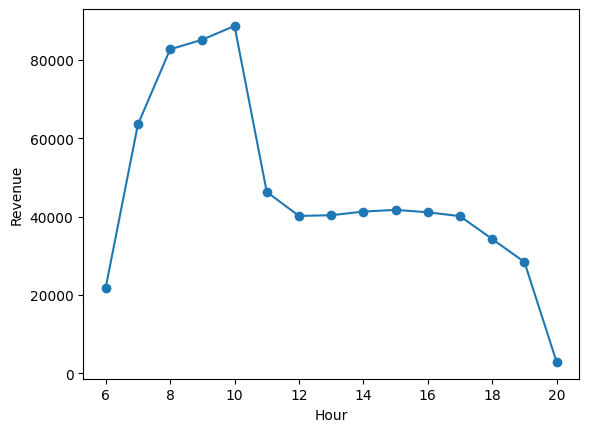

In [7]:
hourly_sales = df.groupby('hour')['revenue'].sum()
hourly_sales
import matplotlib.pyplot as plt

hourly_sales = df.groupby('hour')['revenue'].sum()

plt.plot(hourly_sales.index, hourly_sales.values, marker='o')
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

In [ ]:
#average transaction amount per customer if id is not uniq and its a real data set
df.groupby('transaction_id')['revenue'].mean()
#uniq date time
df['dtime'] = pd.to_datetime(df['transaction_date']+' '+df['transaction_time'],
                          format='%d-%m-%Y %H:%M:%S')
#hour or date wise series as i wish
df['hour'] = df['dtime'].dt.hour
df.groupby('hour')['transaction_qty'].sum().sort_values(ascending=False)
#most popular
df.groupby('product_category')['transaction_qty'].sum().sort_values()
df["product_category"].value_counts()
#number of transaction per store
df.groupby('store_id')['transaction_qty'].count()
df.groupby('store_id')['transaction_id'].count()

store_id
3    50599
5    47782
8    50735
Name: transaction_qty, dtype: int64

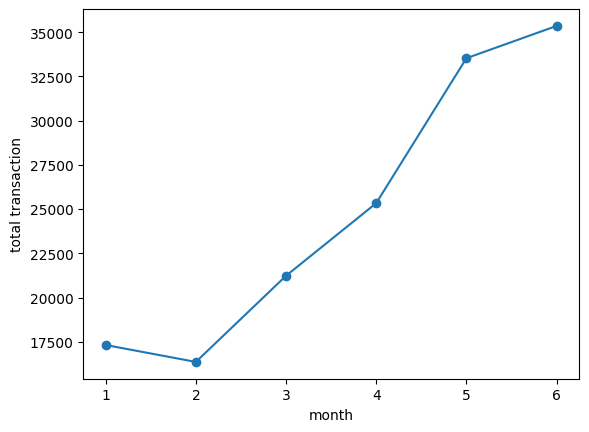

In [8]:
#monthly sales trend
df['datetime'] = pd.to_datetime(df['transaction_date']+' '+df['transaction_time'],
                                format="%d-%m-%Y %H:%M:%S")
df['month'] = df['datetime'].dt.month
#better df['month'] = df['datetime'].dt.to_period('M')
g = df.groupby('month')['transaction_id'].nunique()
plt.plot(g.index,g.values,marker='o')
plt.xlabel('month')
plt.ylabel('total transaction')
plt.show()